# 05 - Descriptive Statistics — Deals

**Goal:** get an overall picture of the distribution of numeric and categorical fields in Deals, and record key observations.

**Structure:**
1. Numeric fields — describe, mode, outliers, distribution plots
2. Categorical fields — frequencies, shares, plots
3. Summary observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')

In [ ]:
print(deals.shape)
print(deals.dtypes)

(21593, 31)
Id                                  object
Deal Owner Name                     object
Closing Date                datetime64[us]
Quality                             object
Stage                               object
Lost Reason                         object
Page                                object
Campaign                            object
SLA                        timedelta64[us]
Content                             object
Term                                object
Source                              object
Payment Type                        object
Product                             object
Education Type                      object
Created Time                datetime64[us]
Course duration                    float64
Months of study                    float64
Initial Amount Paid                float64
Offer Total Amount                 float64
Contact Name                        object
City                                object
Level of Deutsch                    object

In [ ]:
numeric_cols = ['Course duration', 'Months of study', 'Initial Amount Paid', 'Offer Total Amount']
deals[numeric_cols].describe().round(2)

,Course duration,Months of study,Initial Amount Paid,Offer Total Amount
count,3587.00,840.00,4165.00,4185.00
mean,10.20,5.44,950.09,7128.72
std,1.83,2.92,1422.15,4636.02
min,6.00,0.00,0.00,0.00
25%,11.00,3.00,300.00,3000.00
50%,11.00,5.00,1000.00,11000.00
75%,11.00,8.00,1000.00,11000.00
max,11.00,11.00,11500.00,11500.00


In [ ]:
# Summary for Won Confirmed only — financial picture
won_stats = deals.loc[deals['is_won_confirmed'], numeric_cols].describe().round(2)
print(won_stats)

       Course duration  Months of study  Initial Amount Paid  \
count           839.00           839.00               839.00   
mean             10.18             5.45              1166.09   
std               1.85             2.92              1482.91   
min               6.00             1.00                 0.00   
25%              11.00             3.00               500.00   
50%              11.00             5.00              1000.00   
75%              11.00             8.00              1000.00   
max              11.00            11.00             11500.00   

       Offer Total Amount  
count              839.00  
mean              7536.71  
std               3751.37  
min                  0.00  
25%               4000.00  
50%              11000.00  
75%              11000.00  
max              11500.00  


In [ ]:
print("Mode (most frequent value):")
for col in numeric_cols:
    mode_val = deals[col].mode().iloc[0]  # mode() returns a Series — take the first
    count = (deals[col] == mode_val).sum()
    print(f"  {col}: {mode_val} (appears {count} times)")

Мода (самое частое значение):
  Course duration: 11.0 (встречается 3012 раз)
  Months of study: 6.0 (встречается 107 раз)
  Initial Amount Paid: 1000.0 (встречается 2623 раз)
  Offer Total Amount: 11000.0 (встречается 1860 раз)


## Key observations

- **Course duration** — min 6, max 11 months. The 25th, 50th and 75th percentiles are all 11, so ~75% take the 11-month course and the rest 6 months.
- **Months of study** — also 0 to 11. Mode is 6, meaning most students (regardless of course) are currently in their 6th month.
- **Initial Amount Paid** — minimum 0 (anomaly), maximum 11,500 in a single payment.
- **Offer Total Amount** — clients pay 0 to 11,500, mean ~7,128, most frequent 11,000.

Note: this is not enough to define product pricing — detailed price analysis is in `11_payments_products`.

In [ ]:
won_main = deals[
    deals['is_won_confirmed']
    & deals['is_main_product']
    & deals['Payment Type'].isin(['Recurring Payments', 'One Payment'])
].copy()

# Descriptive by Payment Type x Education Type
print("Offer Total Amount by Payment Type x Education Type:")
print(won_main.groupby(['Payment Type', 'Education Type'])['Offer Total Amount']
      .describe().round(0))

print("\nMedians by Product x Education Type x Payment Type:")
print(won_main.groupby(['Product', 'Education Type', 'Payment Type'])['Offer Total Amount']
      .median().round(0))

# More readable format — pivot table
print("\nPivot: median Offer by Product x Education Type (within Payment Type):")
for pt in ['Recurring Payments', 'One Payment']:
    print(f"\n--- {pt} ---")
    pivot = won_main[won_main['Payment Type'] == pt].pivot_table(
        values='Offer Total Amount',
        index='Product',
        columns='Education Type',
        aggfunc='median'
    ).round(0)
    print(pivot)

Offer Total Amount по Payment Type × Education Type:
                                   count    mean     std     min     25%  \
Payment Type       Education Type                                          
One Payment        Evening          43.0  3244.0   527.0  2500.0  3000.0   
                   Morning          83.0  4783.0  3638.0  1200.0  2000.0   
Recurring Payments Evening         127.0  3802.0   387.0  2000.0  3500.0   
                   Morning         577.0  9049.0  3221.0  2000.0  5000.0   

                                       50%      75%      max  
Payment Type       Education Type                             
One Payment        Evening          3000.0   3500.0   4500.0  
                   Morning          3000.0   5000.0  11500.0  
Recurring Payments Evening          4000.0   4000.0   5000.0  
                   Morning         11000.0  11000.0  11500.0  

Медианы по Product × Education Type × Payment Type:
Product            Education Type  Payment Type      
Digit

## Categorical fields — quality, stage, source, product

## Stage

In [ ]:
# Stage distribution (detailed)
print("=== Stage (detailed) ===")
stage_counts = deals['Stage'].value_counts(dropna=False)
stage_share = deals['Stage'].value_counts(normalize=True, dropna=False).round(3) * 100
stage_table = pd.DataFrame({'count': stage_counts, 'share_%': stage_share})
print(stage_table)

# Stage_Group distribution (aggregated)
print("\n=== Stage_Group (derived flag) ===")
sg_counts = deals['Stage_Group'].value_counts(dropna=False)
sg_share = deals['Stage_Group'].value_counts(normalize=True, dropna=False).round(3) * 100
sg_table = pd.DataFrame({'count': sg_counts, 'share_%': sg_share})
print(sg_table)

=== Stage (детально) ===
                           count  share_%
Stage                                    
Lost                       15743     72.9
Call Delayed                2248     10.4
Registered on Webinar       2072      9.6
Payment Done                 858      4.0
Waiting For Payment          325      1.5
Qualificated                 128      0.6
Registered on Offline Day    100      0.5
Need to Call - Sales          33      0.2
Need To Call                  31      0.1
Test Sent                     25      0.1
Need a consultation           23      0.1
New Lead                       6      0.0
Free Education                 1      0.0

=== Stage_Group (по созданному флагу) ===
             count  share_%
Stage_Group                
Lost         15743     72.9
In Progress   4991     23.1
Won            859      4.0


### Findings — Stage and Stage_Group

**Funnel:**
- 73% Lost (15,743) — a large pool of lost clients, the main area for analysis.
- 23% In Progress (4,991) — leads at varying readiness to buy.
- 4% Won (859). Conversion on closed deals: **5.17%** (Won / (Won + Lost)).

**Notable points:**
- Call Delayed is the largest In Progress category (2,248, 45%) — to account for in later analysis.
- Free Education — 1 record, edge case (likely employee/partner).
- Lost (15,743) includes 1,771 duplicates (10.7% of Lost). Adjusting for duplicates, true conversion should be slightly higher.

## Quality

In [ ]:
print("=== Quality (distribution) ===")
q_counts = deals['Quality'].value_counts(dropna=False)
q_share = deals['Quality'].value_counts(normalize=True, dropna=False).round(3) * 100
q_table = pd.DataFrame({'count': q_counts, 'share_%': q_share})
print(q_table)

=== Quality (распределение) ===
                   count  share_%
Quality                          
E - Non Qualified   7634     35.4
D - Non Target      6248     28.9
C - Low             3459     16.0
None                2256     10.4
B - Medium          1564      7.2
A - High             432      2.0


### Findings

64% of leads (D + E) are non-target or unqualified. Either marketing brings in many junk leads, or some D/E leads still buy and the raw share misleads. To verify via cross-tab Quality x Stage_Group.

## Source

In [ ]:
print("=== Source (distribution) ===")
s_counts = deals['Source'].value_counts(dropna=False)
s_share = deals['Source'].value_counts(normalize=True, dropna=False).round(3) * 100
s_table = pd.DataFrame({'count': s_counts, 'share_%': s_share})
print(s_table)

=== Source (распределение) ===
                count  share_%
Source                        
Facebook Ads     4850     22.5
Google Ads       4226     19.6
Organic          2590     12.0
Tiktok Ads       2051      9.5
SMM              1730      8.0
Youtube Ads      1657      7.7
CRM              1656      7.7
Bloggers         1089      5.0
Telegram posts   1001      4.6
Webinar           379      1.8
Partnership       203      0.9
Test              159      0.7
Offline             2      0.0


### Findings — Source

**Top-3 channels by lead volume:**
- Facebook Ads — 4,850 (22.5%)
- Google Ads — 4,226 (19.6%)
- Organic — 2,590 (12%) — free traffic (SEO, direct)

Facebook + Google = 42% of all leads. High concentration: a drop in either strongly affects total flow.

**Channel grouping:**
- Paid (Facebook, Google, Tiktok, Youtube, Bloggers): ~64% of leads
- Organic/content (Organic, SMM, Telegram, Webinar): ~26%
- Partnership/internal (CRM, Partnership, Test, Offline): ~9%

## Product

In [ ]:
print("=== Product (distribution) ===")
p_counts = deals['Product'].value_counts(dropna=False)
p_share = deals['Product'].value_counts(normalize=True, dropna=False).round(3) * 100
p_table = pd.DataFrame({'count': p_counts, 'share_%': p_share})
print(p_table)

=== Product (распределение) ===
                     count  share_%
Product                            
None                 18001     83.4
Digital Marketing     1990      9.2
UX/UI Design          1022      4.7
Web Developer          575      2.7
Find yourself in IT      4      0.0
Data Analytics           1      0.0


### Findings

**Implication for analysis:** all "by product" breakdowns (CR, revenue, unit economics) are computed on a subset of ~17% of deals — to be noted in the report.

**Distribution among filled deals:**
- Digital Marketing — 1,990 (55% of filled) — main product
- UX/UI Design — 1,022 (28%)
- Web Developer — 575 (16%)
- Find yourself in IT — 4, Data Analytics — 1 — edge cases, excluded from product analysis (no statistics)

## Payment Type and Education Type

In [ ]:
print("=== Payment Type (after recovery) ===")
pt_counts = deals['Payment Type'].value_counts(dropna=False)
pt_share = deals['Payment Type'].value_counts(normalize=True, dropna=False).round(3) * 100
pt_table = pd.DataFrame({'count': pt_counts, 'share_%': pt_share})
print(pt_table)

print("\n=== Payment Type among Won Confirmed ===")
won_pt = deals.loc[deals['is_won_confirmed'], 'Payment Type'].value_counts(dropna=False)
won_pt_share = deals.loc[deals['is_won_confirmed'], 'Payment Type'].value_counts(normalize=True, dropna=False).round(3) * 100
won_pt_table = pd.DataFrame({'count': won_pt, 'share_%': won_pt_share})
print(won_pt_table)

print("\n=== Education Type ===")
et_counts = deals['Education Type'].value_counts(dropna=False)
et_share = deals['Education Type'].value_counts(normalize=True, dropna=False).round(3) * 100
et_table = pd.DataFrame({'count': et_counts, 'share_%': et_share})
print(et_table)

print("\n=== Education Type among Won Confirmed ===")
won_et = deals.loc[deals['is_won_confirmed'], 'Education Type'].value_counts(dropna=False)
won_et_share = deals.loc[deals['is_won_confirmed'], 'Education Type'].value_counts(normalize=True, dropna=False).round(3) * 100
won_et_table = pd.DataFrame({'count': won_et, 'share_%': won_et_share})
print(won_et_table)

=== Payment Type (после восстановления) ===
                    count  share_%
Payment Type                      
None                20619     95.5
Recurring Payments    812      3.8
One Payment           157      0.7
Reservation             5      0.0

=== Payment Type среди Won Confirmed ===
                    count  share_%
Payment Type                      
Recurring Payments    711     84.7
One Payment           126     15.0
Reservation             1      0.1
None                    1      0.1

=== Education Type ===
                count  share_%
Education Type                
None            18294     84.7
Morning          2895     13.4
Evening           404      1.9

=== Education Type среди Won Confirmed ===
                count  share_%
Education Type                
Morning           662     78.9
Evening           170     20.3
None                7      0.8


### Findings — Payment Type and Education Type

- **Recurring Payments — 711 (84.7%)** — the vast majority pay monthly
- One Payment — 126 (15%) — single payment (full or partial)
- Reservation — 1, NaN — 1 — edge cases

- **Morning — 662 (78.9%)** — nearly 4 of 5 students study in the morning
- Evening — 170 (20.3%)

## Lost Reason

In [ ]:
print("=== Lost Reason (all deals) ===")
lr_counts = deals['Lost Reason'].value_counts(dropna=False)
lr_share = deals['Lost Reason'].value_counts(normalize=True, dropna=False).round(3) * 100
lr_table = pd.DataFrame({'count': lr_counts, 'share_%': lr_share})
print(lr_table)

print("\n=== Lost Reason for Stage = Lost only ===")
lost_only = deals[deals['Stage'] == 'Lost']
lr_lost = lost_only['Lost Reason'].value_counts(dropna=False)
lr_lost_share = lost_only['Lost Reason'].value_counts(normalize=True, dropna=False).round(3) * 100
lr_lost_table = pd.DataFrame({'count': lr_lost, 'share_%': lr_lost_share})
print(lr_lost_table)

print("\n=== Lost Reason for Stage != Lost (history leak / Next stream) ===")
not_lost = deals[(deals['Stage'] != 'Lost') & deals['Lost Reason'].notna()]
lr_other = not_lost['Lost Reason'].value_counts()
print(lr_other)

=== Lost Reason (все сделки) ===
                                         count  share_%
Lost Reason                                            
None                                      5469     25.3
Doesn't Answer                            4135     19.1
Changed Decision                          2146      9.9
Duplicate                                 1771      8.2
Non target                                1761      8.2
Stopped Answering                         1588      7.4
Invalid number                            1481      6.9
needs time to think                        655      3.0
Expensive                                  626      2.9
Conditions are not suitable                531      2.5
Next stream                                288      1.3
Inadequate                                 176      0.8
Gutstein refusal                           172      0.8
Considering a different direction in IT    148      0.7
Not for myself                             145      0.7
Does not speak 

### Findings — Lost Reason

22 categories.

#### Nature of losses (structure of Lost)

**Contact losses (~52%):**
- Doesn't Answer — 25.9%
- Stopped Answering — 9.9%
- Invalid number — 9.3%
- Didn't leave an application — 0.8%

Half of Lost are leads the manager couldn't reach or who stopped answering — not "didn't buy" but "no conversation happened".

**Not a fit as clients (~22%):**
- Duplicate — 11.1%
- Non target — 11%
- Other (Inadequate, Does not speak English, Not for myself, Computer skills, Considering other direction) — ~5%

Structurally non-target / technical drop-offs.

**Product/price objections (~10%):**
- Changed Decision — 13.5% (vague "changed mind")
- Expensive — 3.9%
- Conditions are not suitable — 3.3%
- Gutschein refusal — 1%
- The contract did not fit — 0.1%

Real product objections. Only ~3.9% are about price.

**Thinking it over / postponed (~5%):**
- needs time to think — 3.8%
- Next stream — 0.8%
- Thought for free — 0.7%

**To competitors:** Went to Rivals — 0.3%

#### Key observations

1. **Real product objections are only ~10% of Lost** (~2,300 deals). The other 90% are losses at the contact stage or non-target leads. Most of the school's "conversion problem" is not the product but lead-generation quality and manager follow-up.
2. **Doesn't Answer (25.9%) is the largest loss zone.** Warrants deeper analysis: relation to Quality, SLA, Source.
3. **Price is a weak objection** (3.9% of Lost). Cutting price is unlikely to fix the main funnel problem.
4. **Gutschein refusal — 1%.**
5. **Duplicate — 11.1% of Lost (1,746 deals).**

#### Lost Reason for Stage != Lost (428 cases)

- Next stream (157) — legitimate use: lead moved to the next cohort, not lost.
- Other ~270 — history leak: manager changed stage but didn't clear Lost Reason. Technical noise, no impact on analysis (filtered via Stage == 'Lost').

## SLA 

In [ ]:
deals['SLA_hours'] = deals['SLA'].dt.total_seconds() / 3600
print(deals['SLA_hours'].describe().round(2))

count    15533.00
mean        32.17
std        204.79
min          0.00
25%          1.22
50%          5.53
75%         15.64
max       7474.57
Name: SLA_hours, dtype: float64


## Charts

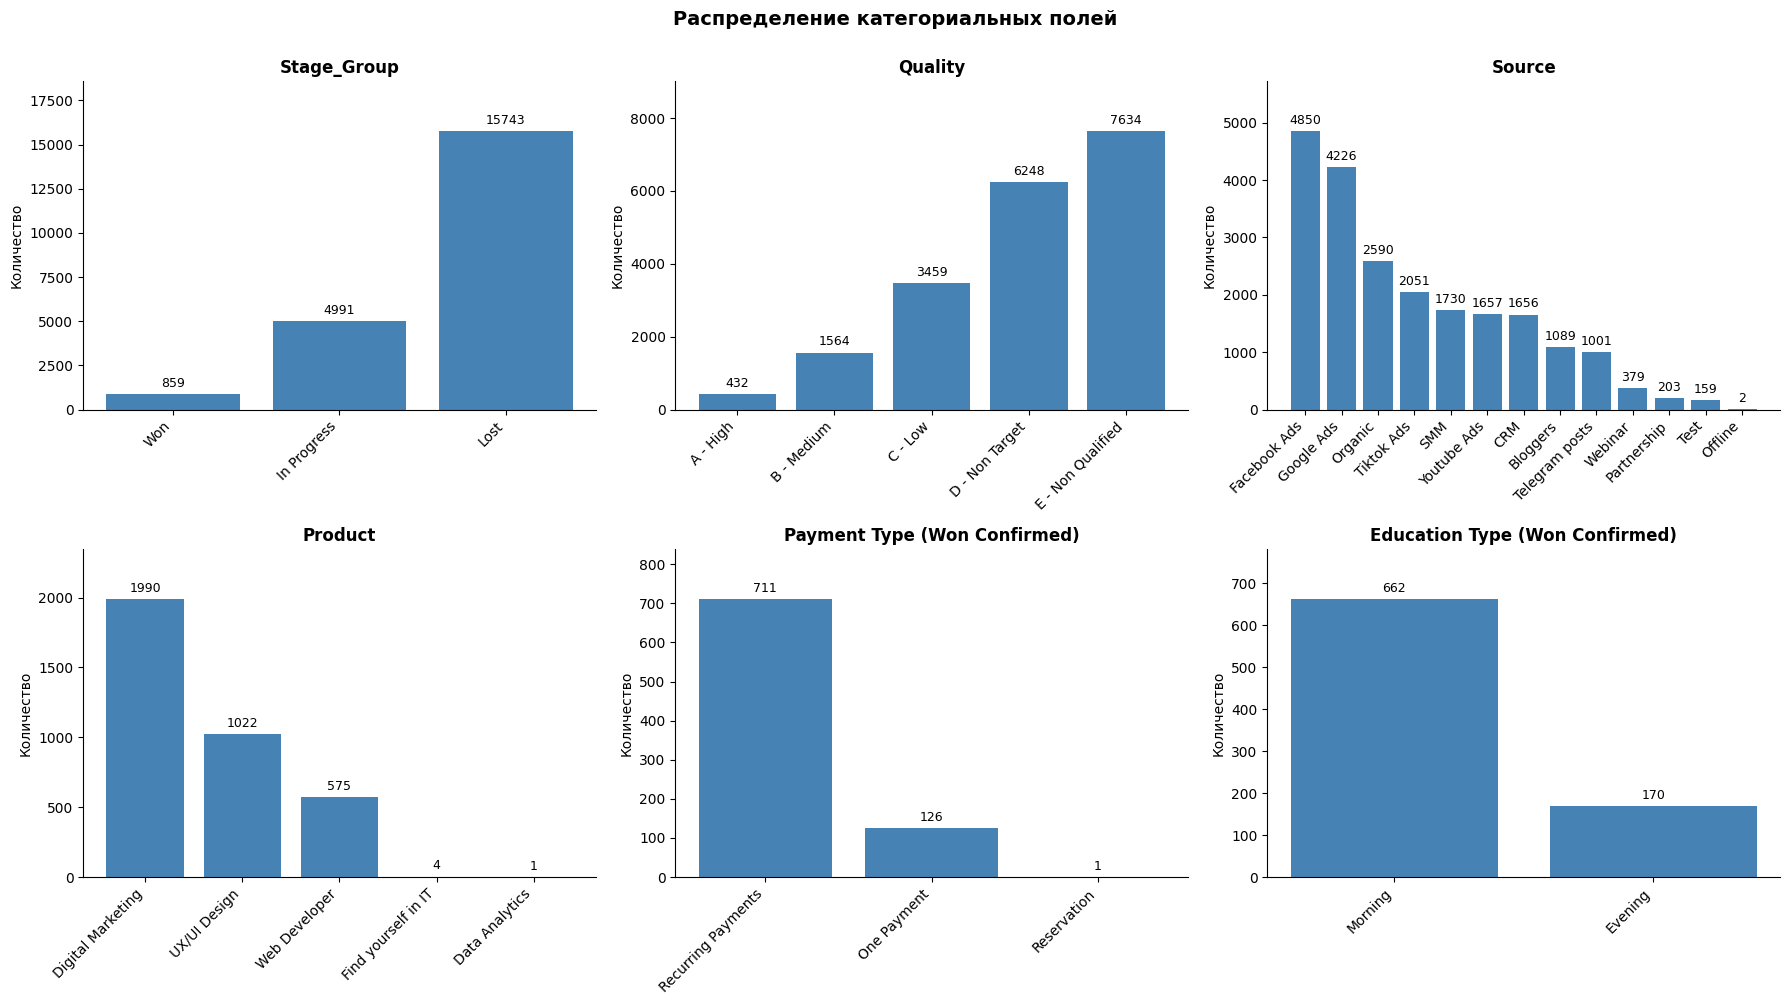

In [ ]:
# Config: field, use Won only, custom order (if needed)
configs = [
    ('Stage_Group',    False, ['Won', 'In Progress', 'Lost']),
    ('Quality',        False, ['A - High', 'B - Medium', 'C - Low',
                               'D - Non Target', 'E - Non Qualified']),
    ('Source',         False, None),                    # descending
    ('Product',        False, None),                    # descending, no NaN
    ('Payment Type',   True,  None),                    # Won only
    ('Education Type', True,  ['Morning', 'Evening']),  # Won only
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, won_only, order) in zip(axes, configs):
    data = deals[deals['is_won_confirmed']] if won_only else deals
    
    # Absolute counts, no NaN
    counts = data[col].value_counts(dropna=True)
    
    if order:
        counts = counts.reindex(order).dropna()
    else:
        counts = counts.sort_values(ascending=False)
    
    bars = ax.bar(range(len(counts)), counts.values, color='steelblue')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right')
    
    title_suffix = ' (Won Confirmed)' if won_only else ''
    ax.set_title(f'{col}{title_suffix}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
    ax.set_ylim(0, counts.max() * 1.18)  # headroom for labels
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribution of categorical fields', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Lost Reason — visualization

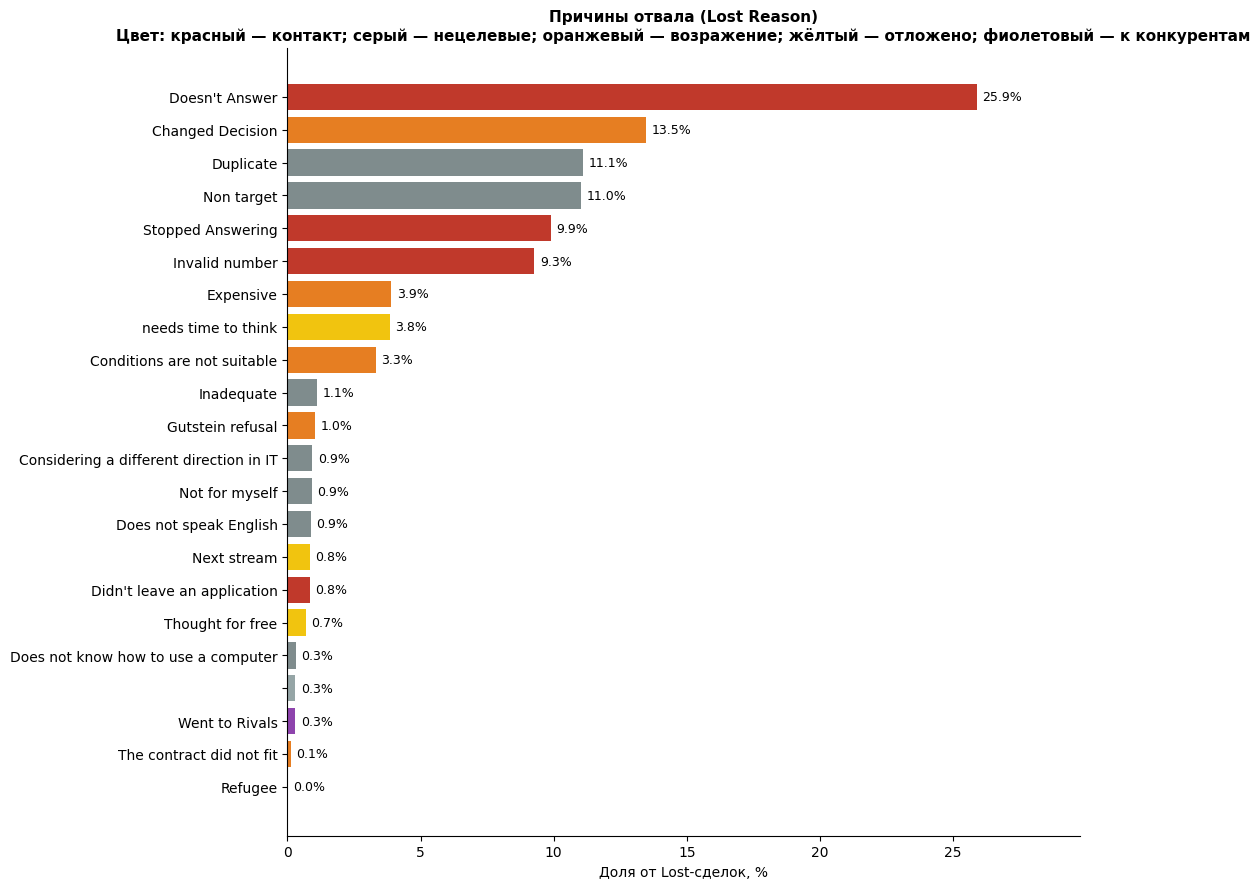

In [ ]:
# Lost deals only
lost = deals[deals['Stage'] == 'Lost']
lr_share = lost['Lost Reason'].value_counts(normalize=True, dropna=False) * 100
lr_share = lr_share.sort_values(ascending=True)  # horizontal bar — bottom to top

# Group by loss nature — color coding
contact_loss = {'Doesn\'t Answer', 'Stopped Answering', 'Invalid number',
                "Didn't leave an application"}
not_client = {'Duplicate', 'Non target', 'Inadequate', 'Does not speak English',
              'Not for myself', 'Considering a different direction in IT',
              'Does not know how to use a computer', 'Refugee'}
product_objection = {'Changed Decision', 'Expensive', 'Conditions are not suitable',
                     'Gutstein refusal', 'The contract did not fit'}
postponed = {'needs time to think', 'Next stream', 'Thought for free'}
rivals = {'Went to Rivals'}

def get_color(reason):
    if reason in contact_loss:       return '#c0392b'  # red — contact failed
    if reason in not_client:         return '#7f8c8d'  # gray — not our client
    if reason in product_objection:  return '#e67e22'  # orange — objection
    if reason in postponed:          return '#f1c40f'  # yellow — postponed
    if reason in rivals:             return '#8e44ad'  # purple — to competitors
    return '#95a5a6'

colors = [get_color(r) for r in lr_share.index]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(range(len(lr_share)), lr_share.values, color=colors)
ax.set_yticks(range(len(lr_share)))
ax.set_yticklabels(lr_share.index)
ax.set_xlabel('Share of Lost deals, %')
ax.set_title('Loss reasons (Lost Reason)\n'
             'Color: red — contact; gray — non-target; '
             'orange — objection; yellow — postponed; purple — to competitors',
             fontsize=11, fontweight='bold')

ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlim(0, lr_share.max() * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

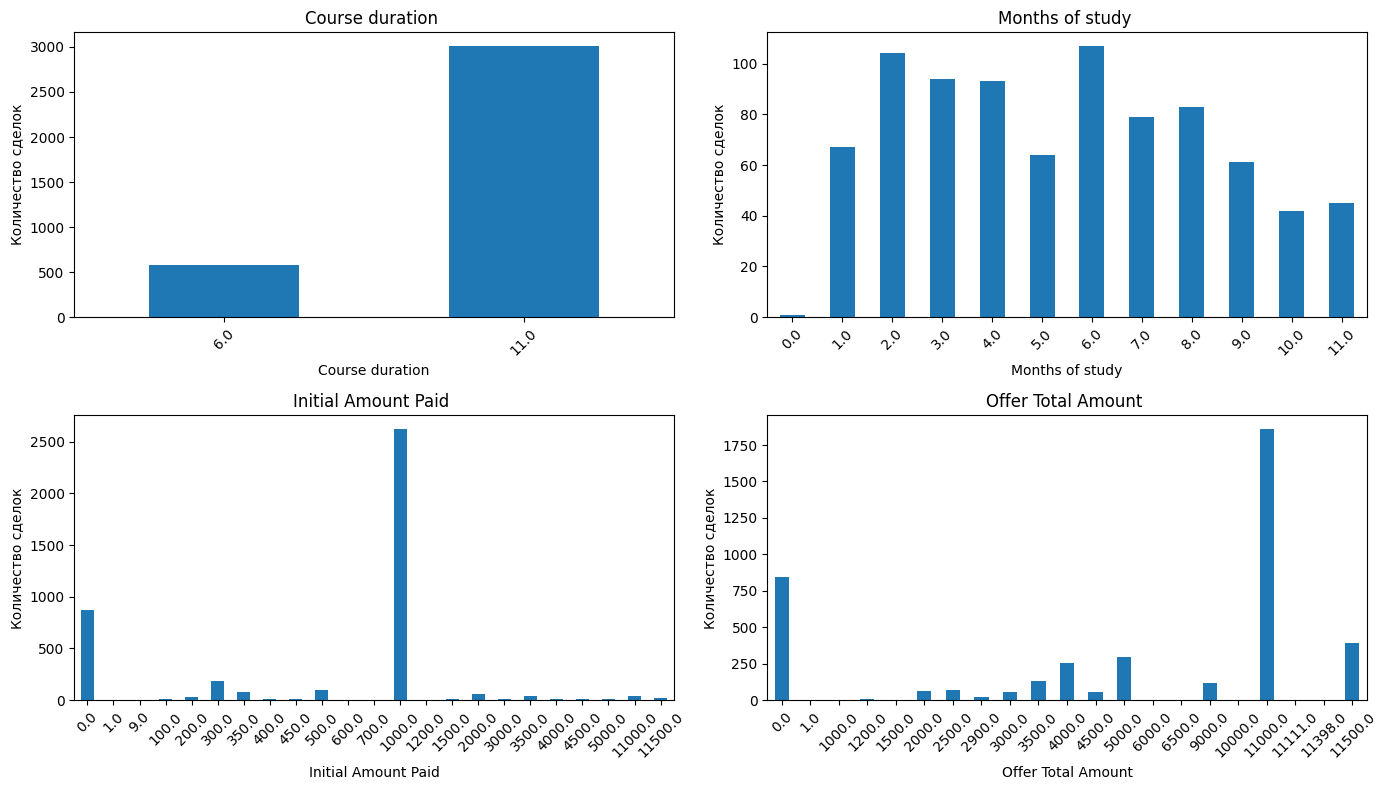

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    top_values = deals[col].value_counts().sort_index()
    top_values.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} ')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of deals')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Findings from the data

- **Course duration:** the charts show 6- and 11-month courses. Most people buy the 11-month course.
- **Months of study:** active students by current month of study. The drop at months 9-11 has two possible explanations: dropout, or lower sales a year ago vs now. To verify later against the deal-creation trend by month. Overall, on average more than 60 students are studying each month.
- **Initial Amount Paid:** the first payment — could be the full sum or part of it. Most people pay 1,000 EUR up front; the next most common is 300 EUR. Many zeros — ambiguous: either a trial course, or the contract is signed but payment hasn't arrived yet.
- **Offer Total Amount:** the full contract price — what the client pays once finished. Most frequent value 11,000 EUR, max 11,500, min 0 (likely trial or artifacts).
- **SLA:** sales response time — from lead submission to manager contact. Mean ~32 hours (high — about a day and a half); max 7,474 hours / 311 days (likely outlier/anomaly); min 0 (near-instant).

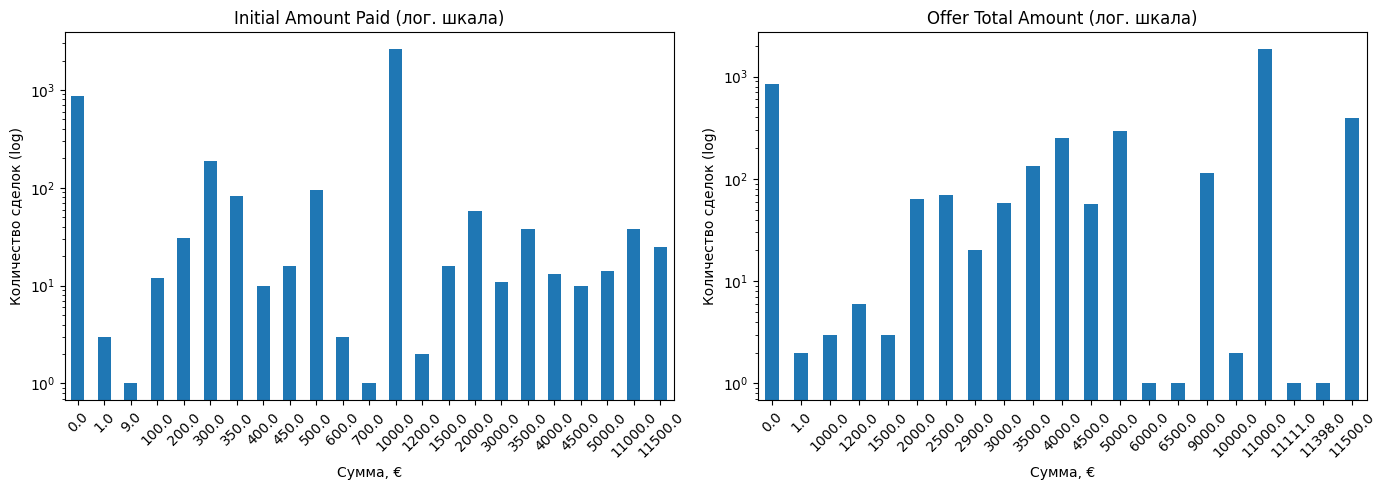

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Initial Amount Paid with log scale
top_initial = deals['Initial Amount Paid'].value_counts().sort_index()
top_initial.plot(kind='bar', ax=axes[0])
axes[0].set_title('Initial Amount Paid (log scale)')
axes[0].set_yscale('log')  # log scale
axes[0].set_xlabel('Amount, EUR')
axes[0].set_ylabel('Number of deals (log)')
axes[0].tick_params(axis='x', rotation=45)

# Offer Total Amount with log scale
top_offer = deals['Offer Total Amount'].value_counts().sort_index()
top_offer.plot(kind='bar', ax=axes[1])
axes[1].set_title('Offer Total Amount (log scale)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Amount, EUR')
axes[1].set_ylabel('Number of deals (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
deals[deals['Course duration'].notna()].groupby('Product')['Course duration'].agg(['mean', 'median', 'count'])

,mean,median,count
Product,,,
Digital Marketing,11.0,11.0,1990
UX/UI Design,11.0,11.0,1022
Web Developer,6.0,6.0,575
